In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, integrated_brier_score, cumulative_dynamic_auc
from sksurv.util import Surv
import shap
import warnings
import pyreadstat
warnings.filterwarnings('ignore')


print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# loading the .dta data set
data, meta = pyreadstat.read_dta("dataset/CMMR71FL.dta")

# Display basic information
print(f"Dataset shape: {data.shape}")
print(f"\nFirst few rows:\n{data.head()}")
print(f"\nData types:\n{data.dtypes}")
print(f"\nMissing values:\n{data.isnull().sum()}")

Dataset shape: (6978, 835)

First few rows:
           mcaseid mv000  mv001  mv002  mv003  mv004    mv005  mv006  mv007  \
0         1 147  1   CM7      1    147      1      1  1012960      7   2018   
1         1 147  7   CM7      1    147      7      1  1012960      7   2018   
2         1 310  1   CM7      1    310      1      1  1012960      7   2018   
3         1 341  1   CM7      1    341      1      1  1012960      7   2018   
4         1 341  3   CM7      1    341      3      1  1012960      7   2018   

   mv008  ...  md123  md124  md125  md126  md127  md128  md129  md130a  \
0   1423  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN   
1   1423  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN   
2   1423  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN   
3   1423  ...    NaN    NaN      0    NaN    NaN    NaN      0       0   
4   1423  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN   

   md130b  md130c  
0     NaN     Na

In [79]:
# selecting only the relevant columns for our analysis
features = ["mv483", "mv483a", "mv012", "mv025", "mv106", "mv190",
             "mv501", "mv130", "mv024", "mv157", "mv158", "mv781"]
data = data[features]

# now renaming the columns to more meaningful names
data.rename(columns={
    "mv483": "circumcision_status",
    "mv483a": "age_circumcision",
    "mv012": "current_age",
    "mv025": "residence",
    "mv106": "education",
    "mv190": "wealth",
    "mv501": "marital_status",
    "mv130": "religion",
    "mv024": "region",
    "mv157": "tv_exposure",
    "mv158": "radio_exposure",
    "mv781": "hiv_testing"
}, inplace=True)

data.head()

,circumcision_status,age_circumcision,current_age,residence,education,wealth,marital_status,religion,region,tv_exposure,radio_exposure,hiv_testing
0,1,95,38,1,2,4,1,4,5,0,1,0
1,1,95,17,1,2,4,0,4,5,0,1,0
2,1,8,50,1,1,2,1,4,5,0,0,0
3,1,95,60,1,0,2,1,4,5,0,0,1
4,1,95,19,1,1,2,0,4,5,0,0,0


In [80]:
# Now handling of the different cases of data 

# dropping rows with unknown values in circumcision_status = 8
data = data[data['circumcision_status'] != 8] # removed 20 

#function to handle the time variable for survival analysis
def compute_time(row):

    if row['circumcision_status'] == 1:
        if row['age_circumcision'] == 95:# age < 5 years
            return 3 # default value for age < 5 years
        if row['age_circumcision'] == 0:
            return 0.25; # changing the 0 to 0.25(for 3 months) for the SSVM model
        else:
            return row['age_circumcision']
    else:
        return row['current_age']


# creating the event and time variables for survival analysis
# event variable: 1 if circumcised, 0 if not circumcised
data['event'] = data['circumcision_status'].apply(lambda x: 1 if x == 1 else 0)
# time variable: time until the event occurs or the study ends
data['time'] = data.apply(compute_time, axis=1)

# Dropping rows with time = 98
data = data[data['time'] != 98] # removed 407 row


# removing circumcision_status and age_circumcision
data.drop(columns=['circumcision_status', 'age_circumcision'], inplace=True)

data.shape # 6551 , 12 columns

(6551, 12)

In [81]:
# converting categorical columns
categorical_columns = ['residence', 'education', 'wealth', 'marital_status', 'religion', 'region', 'tv_exposure', 'radio_exposure', 'hiv_testing']
for col in categorical_columns:
    data[col] = data[col].astype('category')


In [82]:
# checking the event and time variable
data['event'].value_counts()

data['time'].describe()

data.dtypes


current_age          int64
residence         category
education         category
wealth            category
marital_status    category
religion          category
region            category
tv_exposure       category
radio_exposure    category
hiv_testing       category
event                int64
time               float64
dtype: object

In [83]:
X = data.drop(columns=["time", "event"])
y_time = data["time"]
y_event = data["event"]

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_time_train, y_time_test, y_event_train, y_event_test = train_test_split(
    X, y_time, y_event, test_size=0.20, random_state=42
)

In [85]:
# dividing the categorical into nominal and ordinal categorical variables
nominal_categorical_columns = ['residence', 'marital_status', 'religion', 'region', 'hiv_testing']
ordinal_categorical_columns = ['education', 'wealth','tv_exposure', 'radio_exposure']
numerical_columns = ['current_age']

# Encoding the variables according to their types
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        # nominal categorical → one-hot
        ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False),
         nominal_categorical_columns),

        # numeric → scaling
        ("num", StandardScaler(),
         numerical_columns + ordinal_categorical_columns)
    ],
    remainder="drop"
)

# fitting the preprocessor on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# transforming the test data
X_test_processed = preprocessor.transform(X_test)


In [86]:
# Handling the survival data using sksurv's Surv object
y_train = Surv.from_arrays(
    y_event_train.astype(bool),
    y_time_train
)

y_test = Surv.from_arrays(
    y_event_test.astype(bool),
    y_time_test
)


In [87]:
# training the 4 models

# 1.Random Survival Forest model
rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)

rsf.fit(X_train_processed, y_train)

# 2. the grdient survival boosting model
gbsa = GradientBoostingSurvivalAnalysis(
    loss='coxph',
    learning_rate=0.05,
    n_estimators=150,
    max_depth=5,
    subsample=0.8,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42
)
gbsa.fit(X_train_processed, y_train)


# 3. XGB COX model
xgb_cox = xgb.XGBRegressor(
    objective='survival:cox',
    learning_rate=0.1,
    n_estimators=150,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    verbosity=0
)
# Weight events more heavily
sample_weight = np.where(y_event_train == 1, 2.0, 1.0)
xgb_cox.fit(X_train_processed, y_time_train, sample_weight=sample_weight)

# 4. XGB AFT model

y_lower_train = y_time_train.ravel()
y_upper_train = np.where(
    y_event_train == 1,
    y_time_train,   # event observed
    np.inf          # censored
)

dtrain = xgb.DMatrix(
    X_train_processed,
    label_lower_bound=y_lower_train,
    label_upper_bound=y_upper_train
)
dtest_aft = xgb.DMatrix(X_test_processed)

params = {
    "objective": "survival:aft",
    "aft_loss_distribution": "normal",
    "aft_loss_distribution_scale": 1.0,
    "learning_rate": 0.1,
    "max_depth": 6
}

xgb_aft = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
)



models = {
    'RSF': rsf,       
    'GBSA': gbsa,
    'XGB-Cox': xgb_cox,
    'XGB-AFT': xgb_aft,
}

In [88]:

results = []

y_train_surv = Surv.from_arrays(
    y_event_train.astype(bool),
    y_time_train
)

y_test_surv = Surv.from_arrays(
    y_event_test.astype(bool),
    y_time_test
)
t_min = y_time_train.min()
t_max = y_time_train.max()
# Ensure y_test is Surv object
y_test_event = y_test["event"]
y_test_time = y_test["time"]

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")

    try:
        # 1. risk prediction

        # Default: all models should provide risk scores via predict()
        if model_name == 'XGB-AFT':
            risk_pred = model.predict(dtest_aft)
        elif model_name == 'LGBM':
            risk_pred = -model.predict(X_test_processed)
        else:
            risk_pred = model.predict(X_test_processed)

        # 2. C-index

        c_index = concordance_index_censored(
            y_test_event,
            y_test_time,
            risk_pred
        )[0]


        # 3. time-dependent AUC

        try:
            times = np.percentile(y_test_time, [10, 25, 50, 75, 90])

            auc, mean_auc = cumulative_dynamic_auc(
                y_train,
                y_test,
                risk_pred,
                times
            )

            mean_auc = np.mean(auc)

        except Exception:
            mean_auc = np.nan

        # 4. integrated brier score

        try:
            if hasattr(model, "predict_survival_function"):
                surv_funcs = model.predict_survival_function(X_test_processed)

                # correct time grid
                times_grid = np.linspace(
                    t_min,
                    t_max,
                    20
                )

                # convert StepFunctions → matrix (n_samples, n_times)
                surv_matrix = np.array([
                    fn(times_grid) for fn in surv_funcs
                ])

                ibs = integrated_brier_score(
                    y_train_surv,
                    y_test_surv,
                    surv_matrix,
                    times_grid
                )
    
            else:
                ibs = np.nan

        except Exception as e:
            print(f"Model:{model_name} error {e} ")
            ibs = np.nan

        results.append({
            "Model": model_name,
            "C-Index": c_index,
            "Mean AUC": mean_auc,
            "IBS": ibs,
            "Status": "Success"
        })

        print(f"  ✓ C-Index: {c_index:.4f}")

    except Exception as e:
        print(f"  ✗ Error: {str(e)}")

        results.append({
            "Model": model_name,
            "Error": str(e),
            "Status": "Failed"
        })


# final result table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    "C-Index",
    ascending=False,
    na_position="last"
)

results_df


Evaluating RSF...
  ✓ C-Index: 0.6028

Evaluating GBSA...
  ✓ C-Index: 0.7179

Evaluating XGB-Cox...
  ✓ C-Index: 0.7153

Evaluating XGB-AFT...
  ✓ C-Index: 0.2884


,Model,C-Index,Mean AUC,IBS,Status
1,GBSA,0.717936,0.781788,0.066792,Success
2,XGB-Cox,0.715331,0.776791,NaN,Success
0,RSF,0.602802,0.656714,0.064672,Success
3,XGB-AFT,0.288377,0.227234,NaN,Success


In [ ]:
# building the prediction functions


# Extract prediction times from the model ----
# GBSA stores the unique event times it was trained on

best_gbsa = gbsa

prediction_times = best_gbsa.unique_times_


print(type(best_gbsa))
print(best_gbsa.__module__)
print(f"\nModel prediction times: {len(prediction_times)} unique time points")
print(f"Time range: {prediction_times.min():.1f} to {prediction_times.max():.1f}")

# Create the prediction function 

def predict_circumcision_risk(
    current_age,
    region,
    religion,
    residence,
    wealth,
    education,
    marital_status,
    hiv_testing,
    tv_exposure,
    radio_exposure,
    model=best_gbsa,
    preprocessor=preprocessor
):
    """
    Predict circumcision timing for a single individual.
    
    Parameters are raw values (strings/numbers), just like a user would enter.
    
    Returns a dictionary with:
        - survival_curve: dict of {age: probability_uncircumcised}
        - median_age: predicted median circumcision age
        - risk_category: 'HIGH', 'MEDIUM', or 'LOW'
        - predicted_window: string like "13 - 17 years"
    """
    print(hasattr(model, "estimators_"))
    print(model.estimators_ is None)
    
    # 1. Create a DataFrame with the single observation
    input_data = pd.DataFrame({
        'current_age': [current_age],
        'region': [region],
        'religion': [religion],
        'residence': [residence],
        'wealth': [wealth],
        'education': [education],
        'marital_status': [marital_status],
        'hiv_testing': [hiv_testing],
        'tv_exposure': [tv_exposure],
        'radio_exposure': [radio_exposure]
    })
    
    # 2. Apply the same preprocessing as training
    input_processed = preprocessor.transform(input_data)
    print("input processed",input_processed)
    
    # 3. Get survival function

    surv_funcs = model.predict_survival_function(input_processed)
    surv_fn = surv_funcs[0]

    surv_times = surv_fn.x
    surv_probs = surv_fn.y

    print("heeeeeee")

    
    
    # Create a dictionary mapping age → probability
    age_prob_dict = {}
    for t, p in zip(surv_times, surv_probs):
        age = int(round(t))
        if age not in age_prob_dict:
            age_prob_dict[age] = p
    
    # Sort by age
    age_prob_dict = dict(sorted(age_prob_dict.items()))
    
    # 5. Find median circumcision age (where probability drops below 0.5)
    median_age = None
    for age, prob in age_prob_dict.items():
        if prob <= 0.5:
            median_age = age
            break
    
    # If never drops below 0.5, use the last age
    if median_age is None:
        median_age = max(age_prob_dict.keys())
    
    # 6. Determine risk category
    # HIGH: median age > 17 (delayed circumcision = longer vulnerability)
    # MEDIUM: median age 14-17
    # LOW: median age < 14 (early circumcision)
    if median_age > 17:
        risk_category = "LATE"
    elif median_age >= 14:
        risk_category = "MEDIUM"
    else:
        risk_category = "EARLY"
    
    # 7. Predicted window (±2 years around median)
    window_start = max(median_age - 2, min(age_prob_dict.keys()))
    window_end = min(median_age + 2, max(age_prob_dict.keys()))
    predicted_window = f"{window_start} - {window_end} years"
    
    
    # 9. Build return dictionary
    result = {
        'input': {
            'current_age': current_age,
            'region': region,
            'religion': religion,
            'residence': residence,
            'wealth': wealth,
            'education': education,
            'marital_status': marital_status,
            'hiv_testing': hiv_testing,
            'tv_exposure': tv_exposure,
            'radio_exposure': radio_exposure
        },
        'survival_curve': age_prob_dict,
        'median_age': median_age,
        'risk_category': risk_category,
        'predicted_window': predicted_window
    }
    
    return result



print("\n--- Testing Multiple Scenarios ---")

scenarios = [
    {
        'name': 'Urban',
        'params': {
            'current_age': 28, 'region': '12', 'religion': '1',
            'residence': '1', 'wealth': '4', 'education': '2',
            'marital_status': '1', 'hiv_testing': '1',
            'tv_exposure': '1', 'radio_exposure': '1'
        }
    }
]


for scenario in scenarios:
    pred = predict_circumcision_risk(**scenario['params'])
    print(f"\n{scenario['name']}:")
    print(f"{pred['survival_curve']}")
    print(f"  Risk: {pred['risk_category']}, Median Age: {pred['median_age']}, Window: {pred['predicted_window']}")

<class 'sksurv.ensemble.boosting.GradientBoostingSurvivalAnalysis'>
sksurv.ensemble.boosting

Model prediction times: 58 unique time points
Time range: 0.2 to 63.0

--- Testing Multiple Scenarios ---


AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

STEP 3: GROUPED PERMUTATION IMPORTANCE
Total encoded features: 34

Calculating permutation importance...

--- Grouped Feature Importance ---


,original_variable,importance,std
0,region,0.143116,0.005951
1,wealth,0.042835,0.003859
2,religion,0.013962,0.003197
3,current_age,0.005850,0.002834
4,education,0.002764,0.002605
5,hiv_testing,0.002652,0.000935
6,marital_status,0.002441,0.001487
7,tv_exposure,0.000580,0.000533
8,residence,0.000269,0.000580
9,radio_exposure,0.000065,0.000694


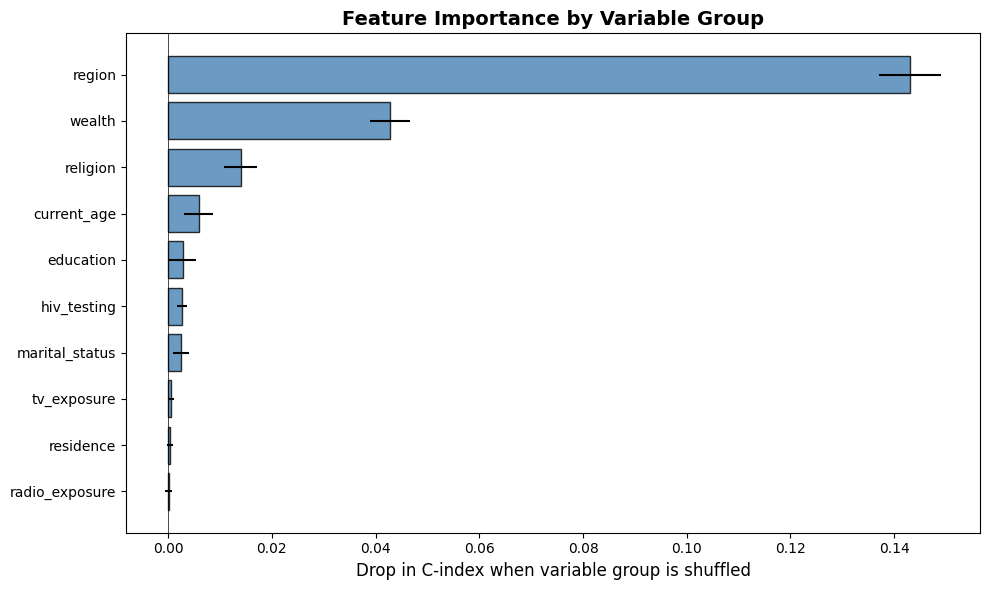

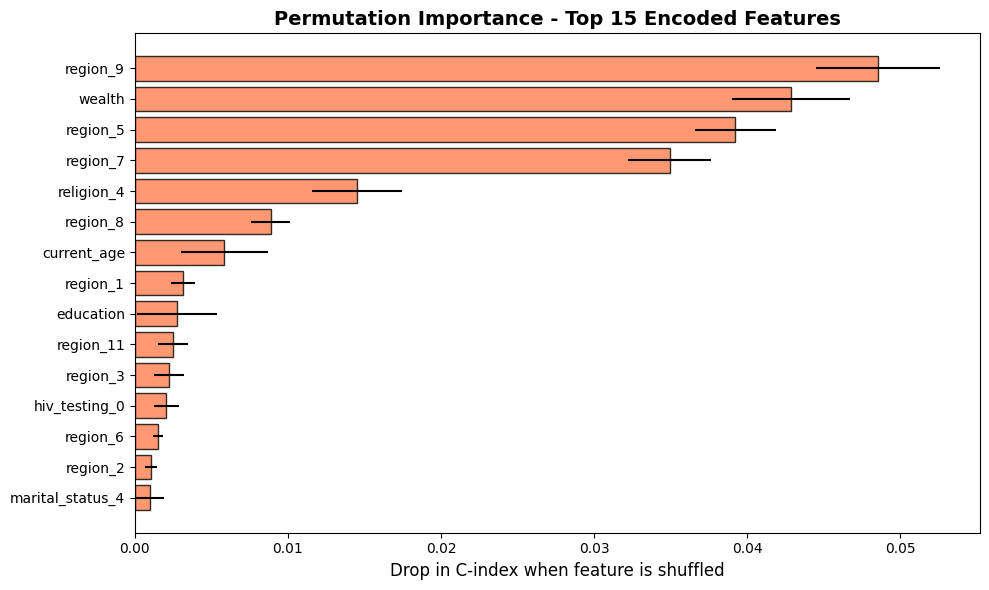

In [ ]:

from sklearn.inspection import permutation_importance


# Get feature names from preprocessor
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = list(cat_encoder.get_feature_names_out(nominal_categorical_columns))
num_feature_names = numerical_columns + ordinal_categorical_columns
all_feature_names = cat_feature_names + num_feature_names

print(f"Total encoded features: {len(all_feature_names)}")

# Define scorer
def concordance_scorer(estimator, X, y):
    risk_scores = estimator.predict(X)
    c_index = concordance_index_censored(y['event'], y['time'], risk_scores)
    return c_index[0]

# Calculate permutation importance on individual encoded features
print("\nCalculating permutation importance...")
perm_result = permutation_importance(
    best_gbsa,
    X_test_processed,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring=concordance_scorer,
    n_jobs=-1
)

# Create DataFrame with individual encoded features
encoded_importance = pd.DataFrame({
    'encoded_feature': all_feature_names,
    'importance': perm_result.importances_mean,
    'std': perm_result.importances_std
})

# ---- GROUP IMPORTANCE BY ORIGINAL VARIABLE ----

# Map each encoded feature back to its original variable
def map_to_original(feature_name, nominal_cols, ordinal_cols, num_cols):
    """Map encoded feature name back to original variable name."""
    # Check if it's a one-hot encoded nominal variable
    for col in nominal_cols:
        if feature_name.startswith(col + '_'):
            return col
    # Check if it's an ordinal or numeric variable
    for col in ordinal_cols + num_cols:
        if feature_name == col:
            return col
    return feature_name

# Add original variable column
encoded_importance['original_variable'] = encoded_importance['encoded_feature'].apply(
    lambda x: map_to_original(x, nominal_categorical_columns, 
                              ordinal_categorical_columns, numerical_columns)
)

# Sum importance for each original variable
grouped_importance = encoded_importance.groupby('original_variable').agg({
    'importance': 'sum',
    'std': lambda x: np.sqrt(np.sum(x**2))  # Combine standard errors
}).sort_values('importance', ascending=False).reset_index()

print("\n--- Grouped Feature Importance ---")
display(grouped_importance)

# ---- PLOT: Grouped Importance ----
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = grouped_importance.sort_values('importance', ascending=True)
bars = ax.barh(plot_data['original_variable'], plot_data['importance'], 
               xerr=plot_data['std'], color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Drop in C-index when variable group is shuffled', fontsize=12)
ax.set_title('Feature Importance by Variable Group', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()


# ---- PLOT: Detailed Breakdown ----
# Show top individual encoded features too
fig, ax = plt.subplots(figsize=(10, 6))
top_encoded = encoded_importance.sort_values('importance', ascending=False).head(15)
top_encoded = top_encoded.sort_values('importance', ascending=True)
ax.barh(top_encoded['encoded_feature'], top_encoded['importance'], 
        xerr=top_encoded['std'], color='coral', edgecolor='black', alpha=0.8)
ax.set_xlabel('Drop in C-index when feature is shuffled', fontsize=12)
ax.set_title('Permutation Importance - Top 15 Encoded Features', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()





In [ ]:
# saving everything

import joblib
import os


# Create directory
os.makedirs('model_artifacts', exist_ok=True)

print("\nSaving model components...")

# 1. Save the tuned model
joblib.dump(best_gbsa, 'model_artifacts/gbsa_model.pkl')
print("✓ gbsa_model.pkl")

# 2. Save the preprocessor
joblib.dump(preprocessor, 'model_artifacts/preprocessor.pkl')
print("✓ preprocessor.pkl")

# 3. Save feature names
joblib.dump(all_feature_names, 'model_artifacts/feature_names.pkl')
print("✓ feature_names.pkl")





Saving model components...
✓ gbsa_model.pkl
✓ preprocessor.pkl
✓ feature_names.pkl


NameError: name 'top_features_shap' is not defined


Top 10 Important Features:
                  Feature  Importance
23          cat__region_9    0.043892
19          cat__region_5    0.039840
21          cat__region_7    0.035968
31            num__wealth    0.017339
22          cat__region_8    0.010885
15          cat__region_1    0.007051
16          cat__region_2    0.004707
25         cat__region_11    0.004601
4   cat__marital_status_2    0.004091
18          cat__region_4    0.003884


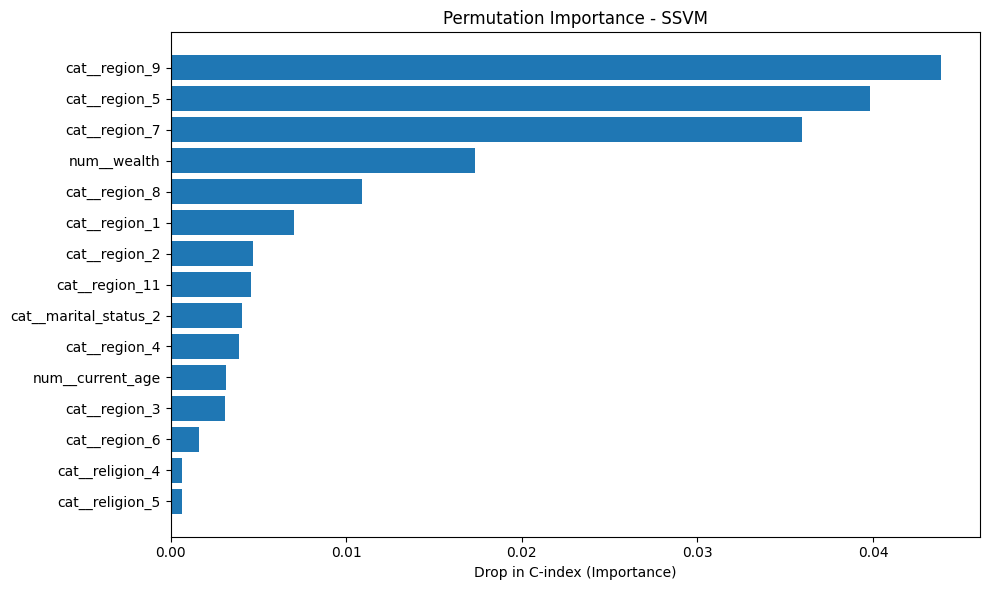


✓ Saved: ssvm_permutation_importance.csv


       Group  Importance
5     region    0.156102
9     wealth    0.017339
3    marital    0.004006
0    current    0.003158
6   religion    0.002735
2        hiv    0.000160
7  residence    0.000145
4      radio    0.000041
8         tv   -0.000311
1  education   -0.001159


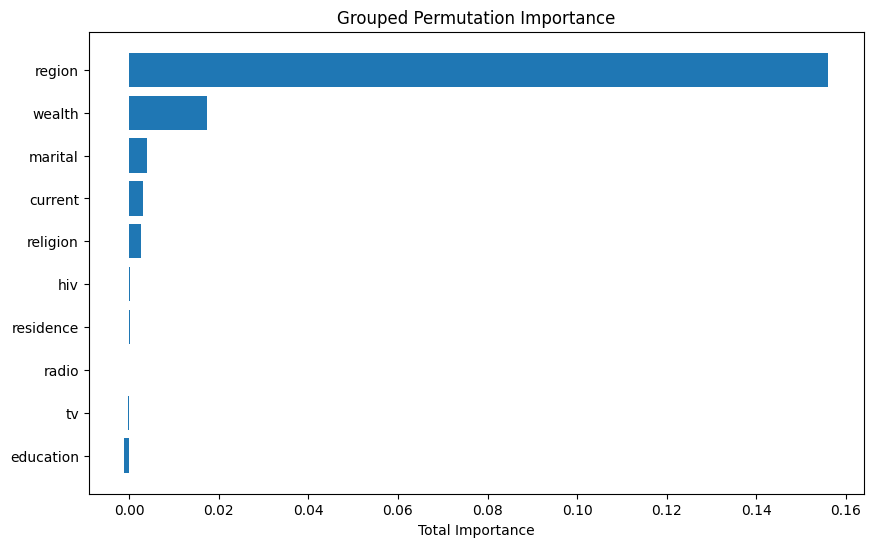

In [ ]:
df = perm_importance_df.copy()

# extract group name (cat__region_1 → region)
df["Group"] = df["Feature"].apply(lambda x: x.split("__")[1].split("_")[0])

grouped_importance = df.groupby("Group")["Importance"].sum().reset_index()

grouped_importance = grouped_importance.sort_values(
    "Importance",
    ascending=False
)

print(grouped_importance)

plt.figure(figsize=(10,6))
plt.barh(grouped_importance["Group"], grouped_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Grouped Permutation Importance")
plt.xlabel("Total Importance")
plt.show()

['ssvm_model.pkl']